# Module 4 — Day 2: Classification in Practice
## PHY 657, Spring 2026

---

## Student mini lectures: 

The last two weeks or so **you** will do the teaching! each pair will pick a topic from below and give a 20 min or so presentation/lecture 

* PCA & dimensionality reduction
* k-means & Gaussian mixture models
* Anomaly detection
* Convolutional neural networks
* Graph neural networks
* Boosted decision trees in practice
* t-SNE & UMAP for visualization
* Simulation-based inference (neural posterior estimation)
* Interpretability & explainability (SHAP values, feature importance)
* your own idea (e.g. how one of these techniques is used in your research?)

## AI ethics 'symposium'

* The last day of class (or maybe last two days) everyone will give a presentation on a topic of your choice, related to the etical issues associated with AI use and the AI industry 
  



### Where we left off

Last time we established:

- Classification assigns a **discrete label** $y \in \{0, 1\}$ from a feature vector $\mathbf{x}$
- A **linear classifier** draws a hyperplane: $g(\mathbf{x}) = \mathbf{w}^T \mathbf{x} + b$
- The **sigmoid function** $\sigma(z) = 1/(1 + e^{-z})$ maps the linear score to a probability
- We evaluate with **confusion matrices** and **ROC curves**

Today we will:
1. **Implement** logistic regression on a classic dataset (Iris)
2. **Apply** it to a simulated physics problem (signal vs background)
3. **Break** the linear classifier and see what alternatives exist

---
## Part 0: Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, accuracy_score
)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'font.size': 14, 'figure.figsize': (8, 6)})

# reproducibility
RNG = np.random.default_rng(42)

---
## Part 1: Logistic Regression on the Iris Dataset

The Iris dataset is the "hello world" of classification. It contains 150 measurements of iris flowers from three species, each described by four features (sepal length, sepal width, petal length, petal width).

We will simplify to a **binary** problem (two species) using **two features** so we can visualize everything in 2D.

In [2]:
# Load Iris and select two classes, two features
iris = datasets.load_iris()

# Use only classes 0 and 1 (setosa vs versicolor)
mask = iris.target != 2
X_iris = iris.data[mask][:, :2]   # sepal length, sepal width
y_iris = iris.target[mask]

print(f"Features: {iris.feature_names[:2]}")
print(f"Classes:  {iris.target_names[:2]}")
print(f"Samples:  {len(y_iris)}  (class 0: {(y_iris==0).sum()}, class 1: {(y_iris==1).sum()})")

Features: ['sepal length (cm)', 'sepal width (cm)']
Classes:  ['setosa' 'versicolor']
Samples:  100  (class 0: 50, class 1: 50)


### 1.1 Visualize the data

Before fitting anything, always look at the data. When you have multiple features, a **pair plot** is a good first step: it shows every pairwise scatter plot, with the 1D distributions on the diagonal. This lets you see which feature combinations separate the classes best.

(We will use all four Iris features and both classes here for exploration, then narrow down to two features for classification.)

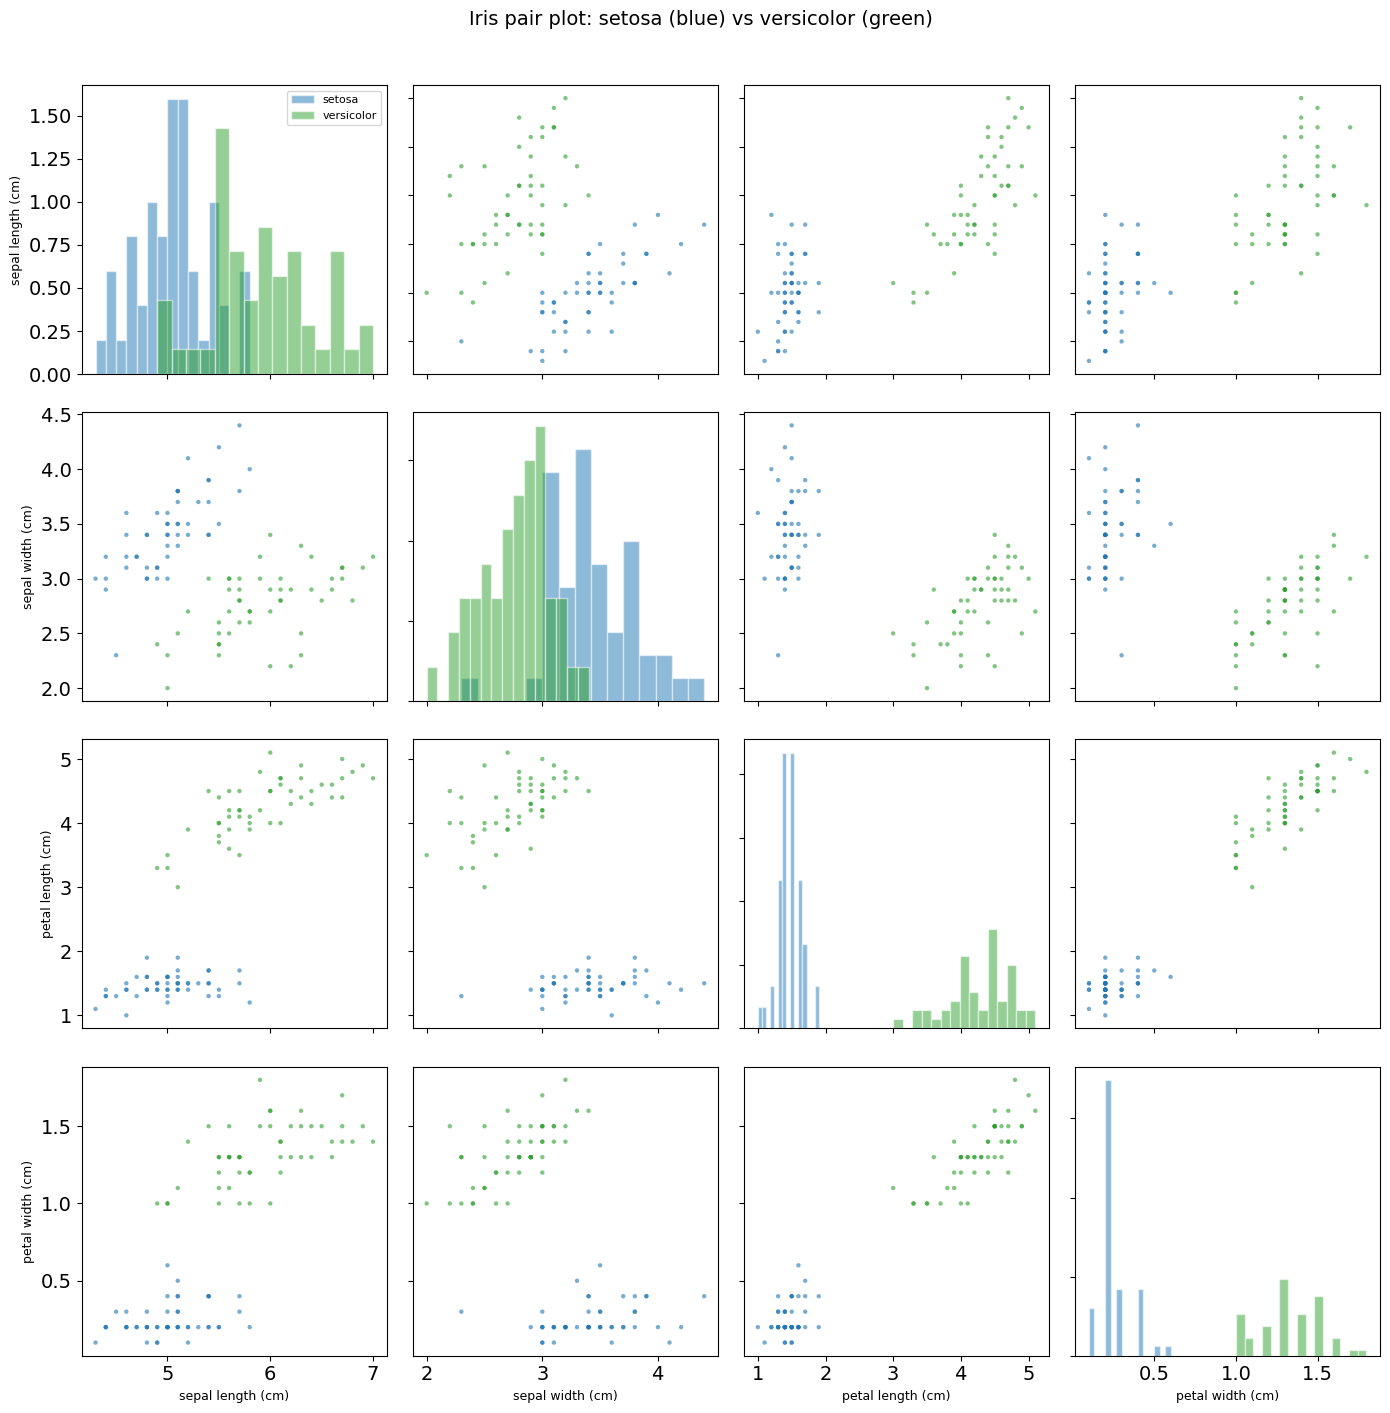

In [3]:
# Full pair plot of all 4 features for the two classes
n_features = 4
feature_names_all = iris.feature_names
class_colors = {0: 'tab:blue', 1: 'tab:green'}
class_labels = {0: iris.target_names[0], 1: iris.target_names[1]}

# Use full 4-feature data for both classes
mask_full = iris.target != 2
X_full = iris.data[mask_full]
y_full = iris.target[mask_full]

fig, axes = plt.subplots(n_features, n_features, figsize=(14, 14))

for i in range(n_features):
    for j in range(n_features):
        ax = axes[i, j]
        if i == j:
            # Diagonal: 1D histograms
            for c in [0, 1]:
                sel = y_full == c
                ax.hist(X_full[sel, i], bins=15, alpha=0.5, density=True,
                        color=class_colors[c], label=class_labels[c], edgecolor='white')
            if i == 0:
                ax.legend(fontsize=8)
        else:
            # Off-diagonal: scatter plots
            for c in [0, 1]:
                sel = y_full == c
                ax.scatter(X_full[sel, j], X_full[sel, i], c=class_colors[c],
                           s=10, alpha=0.6, edgecolors='none')
        
        # Labels on edges only
        if i == n_features - 1:
            ax.set_xlabel(feature_names_all[j], fontsize=9)
        else:
            ax.set_xticklabels([])
        if j == 0:
            ax.set_ylabel(feature_names_all[i], fontsize=9)
        else:
            ax.set_yticklabels([])

fig.suptitle('Iris pair plot: setosa (blue) vs versicolor (green)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**What to notice:**
- The diagonal shows the 1D distribution of each feature for each class. Some features (e.g., petal length) separate the classes cleanly on their own; others (e.g., sepal width) show heavy overlap.
- The off-diagonal scatter plots show pairwise correlations. Some feature *pairs* separate the classes better than either feature alone.
- For the rest of Part 1, we will use just two features (sepal length and sepal width) — these have moderate overlap, making the classification problem non-trivial but still manageable.

In a real experiment, you would do exactly this: look at all your measured quantities, identify which ones carry discriminating power, and then decide which to feed into the classifier.

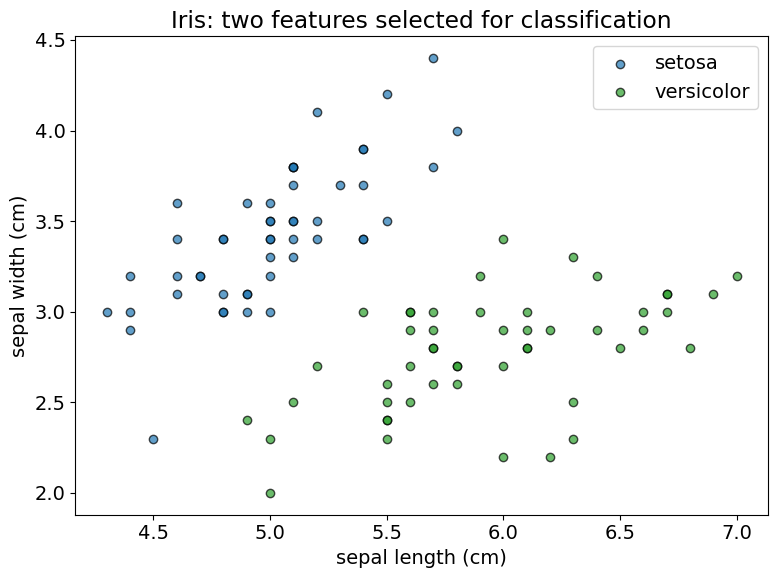

In [4]:
# Quick scatter of just the two features we'll use for classification
fig, ax = plt.subplots()
for c, name, color in zip([0, 1], iris.target_names[:2], ['tab:blue', 'tab:green']):
    sel = y_iris == c
    ax.scatter(X_iris[sel, 0], X_iris[sel, 1], label=name, c=color, edgecolors='k', alpha=0.7)
ax.set_xlabel(iris.feature_names[0])
ax.set_ylabel(iris.feature_names[1])
ax.legend()
ax.set_title('Iris: two features selected for classification')
plt.tight_layout()
plt.show()

### 1.2 Train/test split

Recall from last time: we **never** evaluate a classifier on the data it was trained on.

The test set is our "mock future experiment."

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42
)
print(f"Training samples: {len(y_train)},  Test samples: {len(y_test)}")

Training samples: 70,  Test samples: 30


### 1.3 Fit logistic regression

Scikit-learn's `LogisticRegression` does exactly what we derived:

$$P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x} + b)$$

It finds $\mathbf{w}$ and $b$ by maximizing the log-likelihood (equivalently, minimizing the cross-entropy loss).

In [6]:
clf_lr = LogisticRegression()
clf_lr.fit(X_train, y_train)

print(f"Weights w = {clf_lr.coef_[0]}")
print(f"Bias    b = {clf_lr.intercept_[0]:.3f}")
print(f"\nTest accuracy = {clf_lr.score(X_test, y_test):.2%}")

Weights w = [ 2.73580778 -2.58510174]
Bias    b = -6.733

Test accuracy = 100.00%


### 1.4 Visualize the decision boundary and probability map

This is the key picture: the classifier carves feature space into two regions separated by a **line** (the decision boundary $\mathbf{w}^T\mathbf{x} + b = 0$). The color intensity shows the predicted probability.

In [7]:
def plot_decision_boundary(clf, X, y, ax=None, title='', feature_names=None, class_names=None):
    """Plot 2D decision boundary with probability shading."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    # create mesh
    margin = 0.5
    x_min, x_max = X[:, 0].min() - margin, X[:, 0].max() + margin
    y_min, y_max = X[:, 1].min() - margin, X[:, 1].max() + margin
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    
    # predict probabilities on mesh
    Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    Z = Z.reshape(xx.shape)
    
    # plot
    cf = ax.contourf(xx, yy, Z, levels=np.linspace(0, 1, 21), cmap='RdYlBu_r', alpha=0.6)
    ax.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
    
    colors = ['tab:blue', 'tab:green']
    for c in np.unique(y):
        sel = y == c
        label = class_names[c] if class_names is not None else f'class {c}'
        ax.scatter(X[sel, 0], X[sel, 1], c=colors[c], edgecolors='k', label=label, alpha=0.8)
    
    if feature_names is not None:
        ax.set_xlabel(feature_names[0])
        ax.set_ylabel(feature_names[1])
    ax.legend()
    ax.set_title(title)
    plt.colorbar(cf, ax=ax, label='P(class 1)')
    return ax

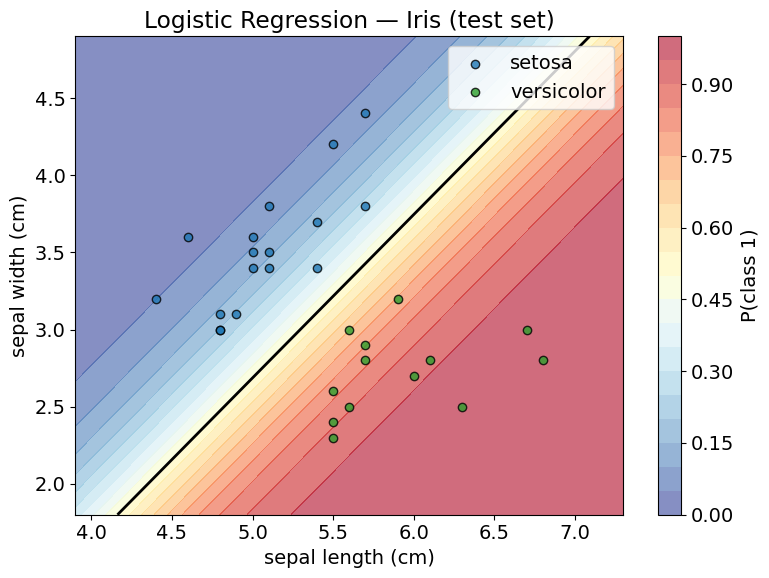

In [8]:
plot_decision_boundary(
    clf_lr, X_test, y_test,
    title='Logistic Regression — Iris (test set)',
    feature_names=iris.feature_names[:2],
    class_names=list(iris.target_names[:2])
)
plt.tight_layout()
plt.show()

### 1.5 Confusion matrix and ROC curve

standard tools for evaluating classifier performance:

- **Confusion matrix**: counts of TP, FP, TN, FN
- **ROC curve**: true positive rate vs false positive rate as we sweep the decision threshold
- **AUC**

#### What is the AUC?

The **AUC** (Area Under the ROC Curve) is exactly what it sounds like: the area under the ROC plot. It ranges from 0.5 (random guessing — the diagonal) to 1.0 (perfect separation).

It has a clean probabilistic interpretation: the AUC is the probability that a randomly chosen class-1 event receives a *higher* classifier score than a randomly chosen class-0 event. In physics language: if you pick one signal event and one background event at random, the AUC is the probability the classifier ranks the signal higher.

This makes AUC insensitive to class imbalance — it only depends on how well the classifier *ranks* events, not on how many of each class there are. We will see why this matters in Part 2.

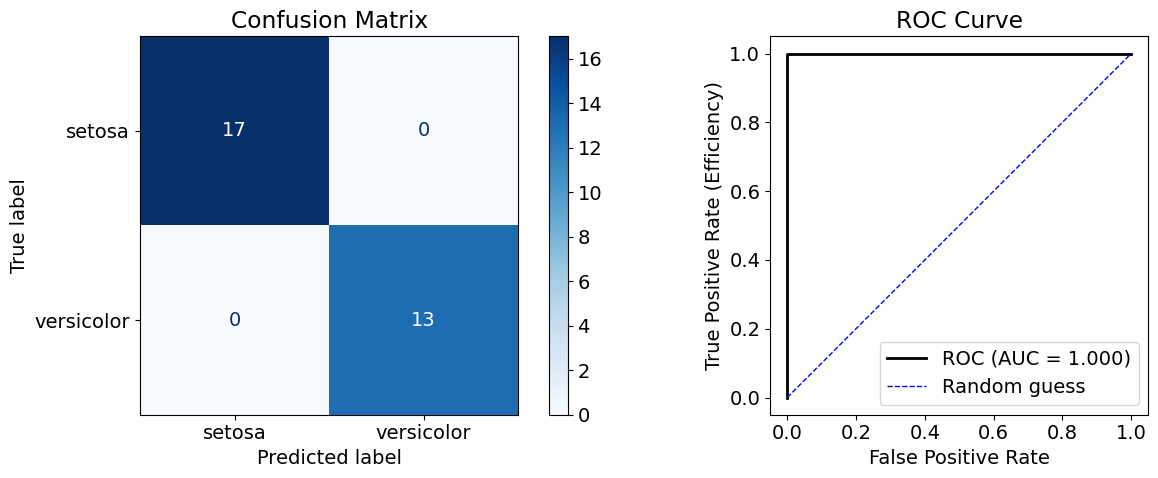

In [10]:
y_pred = clf_lr.predict(X_test)
y_prob = clf_lr.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=iris.target_names[:2]).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix')

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, 'k-', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'b--', lw=1, label='Random guess')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Efficiency)')
axes[1].legend()
axes[1].set_title('ROC Curve')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

**Discussion point:** The Iris setosa vs versicolor problem is almost perfectly linearly separable. This is the *easy* case. What happens when classes overlap more?

---
## Part 2: Physics Application — A Dark Matter Search

Now let's move to a problem that looks like a real rare-event search.

Imagine a dark matter detector that records three features for every event:
- **Energy** (from the optimal filter — Module 3!)
- **Rise time** of the pulse
- **$\chi^2$** of the optimal filter fit (goodness-of-fit — also Module 3)

Signal events (dark matter interactions) are **rare**. Background events (from radioactive decays, noise triggers, etc.) are **abundant**. Both populations overlap in feature space.

We model each class as a 3D Gaussian:

$\mathbf{x}_{\text{signal}} \sim \mathcal{N}(\boldsymbol{\mu}_s,\, \Sigma_s)$
$\mathbf{x}_{\text{background}} \sim \mathcal{N}(\boldsymbol{\mu}_b,\, \Sigma_b)$

The key difficulty is not the distance between the means — it is that **signal is extremely rare**. A classifier that always says 'background' can achieve very high accuracy while being completely useless for the physics goal.

In [11]:
def generate_dm_search(n_total=5000, signal_fraction=0.05, rng=None):
    """
    Simulate a dark matter search dataset with 3 features:
      - energy, rise time, chi-squared
    Signal is rare; background is abundant.
    """
    if rng is None:
        rng = np.random.default_rng()
    
    n_sig = int(n_total * signal_fraction)
    n_bkg = n_total - n_sig
    
    # Signal: low energy, fast rise time, good chi2
    mu_sig = np.array([12.0, 0.8, 1.1])
    cov_sig = np.array([[4.0, -0.5, 0.2],
                        [-0.5, 0.04, -0.01],
                        [0.2, -0.01, 0.15]])
    
    # Background: higher energy, slower rise time, worse chi2
    mu_bkg = np.array([18.0, 1.3, 2.5])
    cov_bkg = np.array([[9.0, 0.8, 0.5],
                        [0.8, 0.09, 0.02],
                        [0.5, 0.02, 0.6]])
    
    X_sig = rng.multivariate_normal(mu_sig, cov_sig, size=n_sig)
    X_bkg = rng.multivariate_normal(mu_bkg, cov_bkg, size=n_bkg)
    
    X = np.vstack([X_sig, X_bkg])
    y = np.concatenate([np.ones(n_sig), np.zeros(n_bkg)]).astype(int)  # 1 = signal
    
    # shuffle
    idx = rng.permutation(len(y))
    return X[idx], y[idx], ['energy (keV)', 'rise time (ms)', '$\\chi^2$ / dof']

### 2.1 Visualize the 3D feature space

We have 3 features, so let's look at all three pairwise projections. Notice that the classes separate differently depending on which features you look at.

Total events: 5000
Signal: 250  (5.0%)
Background: 4750  (95.0%)


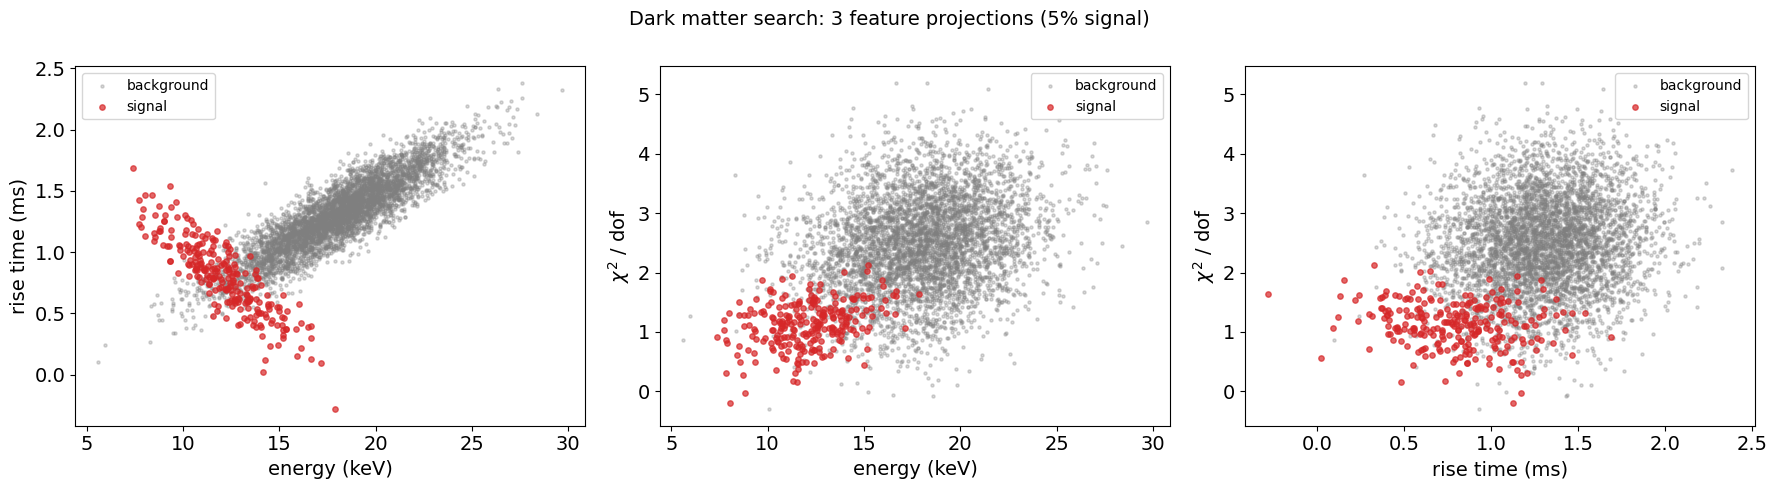

In [12]:
X_dm, y_dm, feat_names = generate_dm_search(n_total=5000, signal_fraction=0.05, rng=RNG)

print(f"Total events: {len(y_dm)}")
print(f"Signal: {y_dm.sum()}  ({y_dm.mean():.1%})")
print(f"Background: {(y_dm == 0).sum()}  ({(y_dm == 0).mean():.1%})")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pairs = [(0, 1), (0, 2), (1, 2)]

for ax, (i, j) in zip(axes, pairs):
    # plot background first (majority) so signal is visible on top
    bkg = y_dm == 0
    sig = y_dm == 1
    ax.scatter(X_dm[bkg, i], X_dm[bkg, j], c='tab:gray', s=5, alpha=0.3, label='background')
    ax.scatter(X_dm[sig, i], X_dm[sig, j], c='tab:red', s=15, alpha=0.7, label='signal')
    ax.set_xlabel(feat_names[i])
    ax.set_ylabel(feat_names[j])
    ax.legend(fontsize=10)

fig.suptitle('Dark matter search: 3 feature projections (5% signal)', fontsize=14)
plt.tight_layout()
plt.show()

### 2.2 Classify with logistic regression (all 3 features)

A nice property of linear classifiers: they work in *any* number of dimensions. The decision boundary is now a **plane** in 3D feature space.

We will train on all 3 features but visualize the boundary projected onto the two most discriminating features.

In [13]:
X_tr_dm, X_te_dm, y_tr_dm, y_te_dm = train_test_split(
    X_dm, y_dm, test_size=0.3, random_state=0, stratify=y_dm
)

clf_dm = LogisticRegression()
clf_dm.fit(X_tr_dm, y_tr_dm)

y_pred_dm = clf_dm.predict(X_te_dm)
y_prob_dm = clf_dm.predict_proba(X_te_dm)[:, 1]

acc_dm = accuracy_score(y_te_dm, y_pred_dm)
print(f"Test accuracy: {acc_dm:.2%}")
print(f"\nBut wait — what accuracy would we get by always predicting 'background'?")
print(f"Always-background accuracy: {(y_te_dm == 0).mean():.2%}")

Test accuracy: 97.47%

But wait — what accuracy would we get by always predicting 'background'?
Always-background accuracy: 95.00%


### The imbalance trap

**Accuracy is misleading for imbalanced problems!** A trivial classifier that always says 'background' achieves ~95% accuracy — but detects zero dark matter events.

This is why in rare-event physics we care about the **ROC curve** and **signal efficiency vs background rejection**, not raw accuracy.

Think about what matters for the physics:
- **Signal efficiency** (TPR): what fraction of real dark matter events do we keep?
- **Background rejection** (1 − FPR): what fraction of background do we eliminate?

These are exactly the axes of the ROC curve.

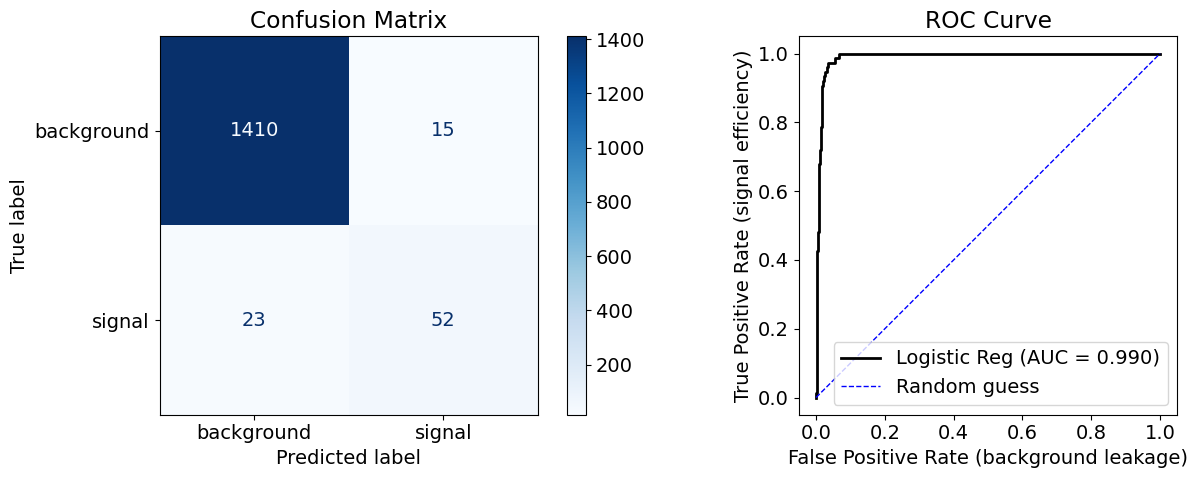

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm_dm = confusion_matrix(y_te_dm, y_pred_dm)
ConfusionMatrixDisplay(cm_dm, display_labels=['background', 'signal']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix')

# ROC curve
fpr_dm, tpr_dm, thresh_dm = roc_curve(y_te_dm, y_prob_dm)
roc_auc_dm = auc(fpr_dm, tpr_dm)
axes[1].plot(fpr_dm, tpr_dm, 'k-', lw=2, label=f'Logistic Reg (AUC = {roc_auc_dm:.3f})')
axes[1].plot([0, 1], [0, 1], 'b--', lw=1, label='Random guess')
axes[1].set_xlabel('False Positive Rate (background leakage)')
axes[1].set_ylabel('True Positive Rate (signal efficiency)')
axes[1].legend()
axes[1].set_title('ROC Curve')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

### 2.3 The effect of signal rarity

In a real dark matter experiment, the signal rate is unknown — it could be 1 in 100 events, or 1 in 10,000. Let's see how the classifier's **useful** performance (AUC, not accuracy) changes as signal becomes rarer.

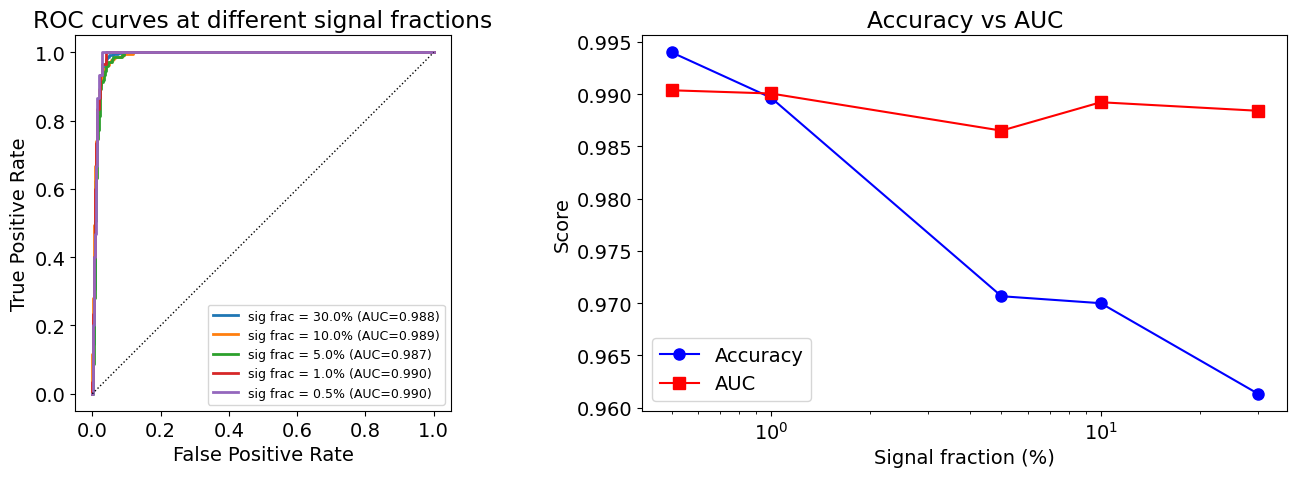

In [15]:
sig_fractions = [0.30, 0.10, 0.05, 0.01, 0.005]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

acc_list = []
auc_list = []

for sf in sig_fractions:
    X_tmp, y_tmp, _ = generate_dm_search(n_total=10000, signal_fraction=sf,
                                          rng=np.random.default_rng(42))
    Xtr_t, Xte_t, ytr_t, yte_t = train_test_split(
        X_tmp, y_tmp, test_size=0.3, random_state=0, stratify=y_tmp
    )
    
    clf_t = LogisticRegression()
    clf_t.fit(Xtr_t, ytr_t)
    
    acc_list.append(clf_t.score(Xte_t, yte_t))
    
    yp_t = clf_t.predict_proba(Xte_t)[:, 1]
    fpr_t, tpr_t, _ = roc_curve(yte_t, yp_t)
    auc_t = auc(fpr_t, tpr_t)
    auc_list.append(auc_t)
    
    axes[0].plot(fpr_t, tpr_t, lw=2, label=f'sig frac = {sf:.1%} (AUC={auc_t:.3f})')

axes[0].plot([0, 1], [0, 1], 'k:', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)
axes[0].set_title('ROC curves at different signal fractions')
axes[0].set_aspect('equal')

# Accuracy vs AUC
ax2 = axes[1]
ax2.plot([sf * 100 for sf in sig_fractions], acc_list, 'bo-', label='Accuracy', markersize=8)
ax2.plot([sf * 100 for sf in sig_fractions], auc_list, 'rs-', label='AUC', markersize=8)
ax2.set_xlabel('Signal fraction (%)')
ax2.set_ylabel('Score')
ax2.set_title('Accuracy vs AUC')
ax2.legend()
ax2.set_xscale('log')

plt.tight_layout()
plt.show()

### Key observations

- **Accuracy increases** as signal becomes rarer — because it's easier to be 'right' when almost everything is background. This is exactly the wrong conclusion!
- **AUC stays roughly constant** — it measures the classifier's intrinsic ability to rank signal above background, regardless of how many of each there are
- The ROC curves nearly overlap because the *class-conditional distributions* are the same in every case — only the mixing proportion changed
- **Lesson for experimentalists:** never report accuracy alone in a rare-event search. The ROC curve (or equivalently, signal efficiency at a fixed background rejection) is the meaningful figure of merit.

In your homework, you will explore a related question: what happens when the class *distributions* overlap more (controlled by mean separation $\Delta\mu$), with balanced classes.

### 2.4 Which features matter?

The logistic regression weights $\mathbf{w}$ tell us directly how much each feature contributes to the classification. This is one of the big advantages of a linear model — it is **interpretable**.

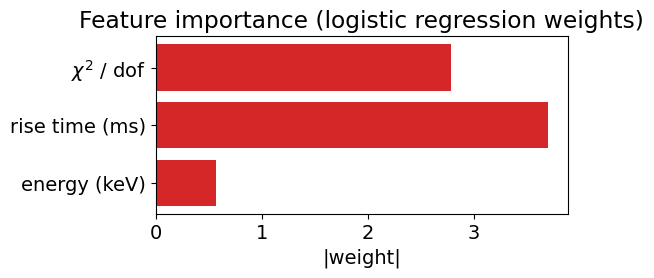

Weights: {'energy (keV)': '-0.572', 'rise time (ms)': '-3.701', '$\\chi^2$ / dof': '-2.780'}
Bias:    13.595

Negative weight on energy → lower energy favors signal
Positive weight on chi2 → higher chi2 favors... background


In [16]:
fig, ax = plt.subplots(figsize=(6, 3))
w = clf_dm.coef_[0]
colors = ['tab:red' if wi < 0 else 'tab:blue' for wi in w]
ax.barh(feat_names, np.abs(w), color=colors)
ax.set_xlabel('|weight|')
ax.set_title('Feature importance (logistic regression weights)')
plt.tight_layout()
plt.show()

print("Weights:", {name: f"{wi:.3f}" for name, wi in zip(feat_names, w)})
print(f"Bias:    {clf_dm.intercept_[0]:.3f}")
print("\nNegative weight on energy → lower energy favors signal")
print("Positive weight on chi2 → higher chi2 favors... background")

---
## Part 3: When Linear Classification Fails

The linear classifier assumes the boundary between classes is a hyperplane. What if the true boundary is curved?

### A non-linearly-separable problem

Consider a detector where signal events form a compact cluster at the center, and background events surround it in a ring. No straight line can separate these.

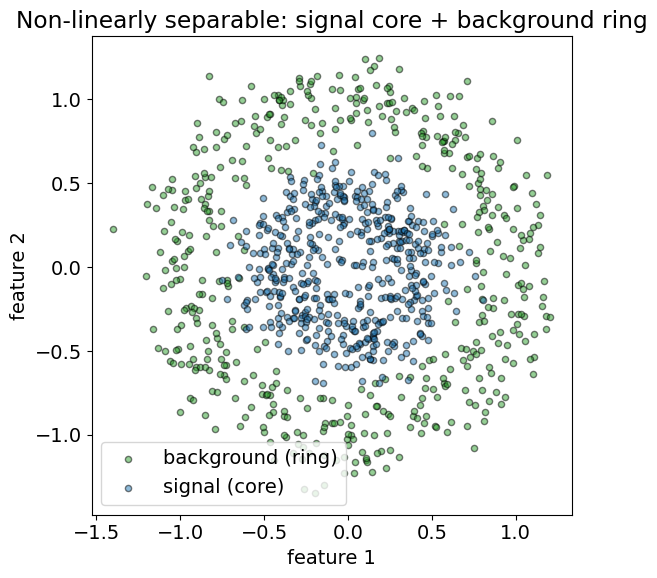

In [17]:
# Generate concentric ring data ("moons" or "circles")
from sklearn.datasets import make_circles

X_circ, y_circ = make_circles(n_samples=1000, noise=0.15, factor=0.4, random_state=42)

fig, ax = plt.subplots()
for c, name, color in zip([0, 1], ['background (ring)', 'signal (core)'], ['tab:green', 'tab:blue']):
    sel = y_circ == c
    ax.scatter(X_circ[sel, 0], X_circ[sel, 1], c=color, label=name, edgecolors='k', alpha=0.5, s=20)
ax.set_xlabel('feature 1')
ax.set_ylabel('feature 2')
ax.legend()
ax.set_title('Non-linearly separable: signal core + background ring')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### 3.1 Logistic regression on the ring problem

Let's see how the linear classifier handles this.

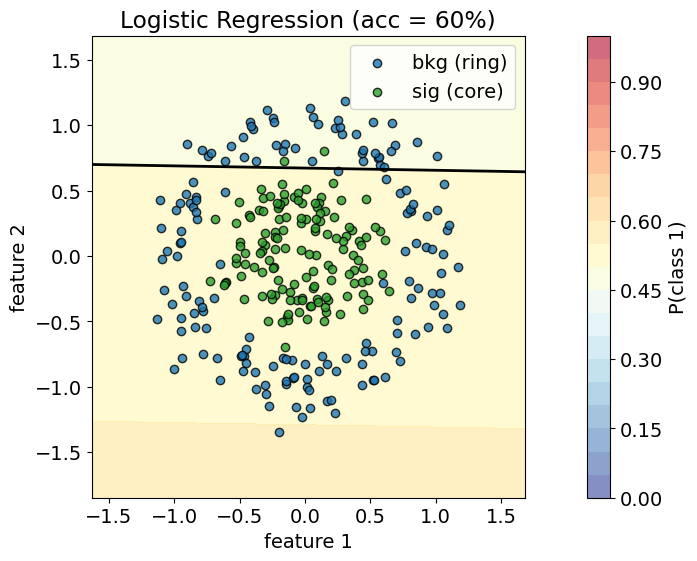

In [19]:
Xtr_c, Xte_c, ytr_c, yte_c = train_test_split(X_circ, y_circ, test_size=0.3, random_state=0)

clf_lr_circ = LogisticRegression()
clf_lr_circ.fit(Xtr_c, ytr_c)

fig, axes = plt.subplots(1, 1, figsize=(16, 6))

plot_decision_boundary(
    clf_lr_circ, Xte_c, yte_c, ax=axes,
    title=f'Logistic Regression (acc = {clf_lr_circ.score(Xte_c, yte_c):.0%})',
    feature_names=['feature 1', 'feature 2'],
    class_names=['bkg (ring)', 'sig (core)']
)
axes.set_aspect('equal')

The linear boundary fails — it cuts straight through both classes.

### 3.2 K-Nearest Neighbors (KNN)

**Idea:** Instead of learning a global boundary, classify each point by looking at its $k$ closest neighbors in the training set and taking a majority vote.

- **No assumptions** about the shape of the boundary
- Boundary adapts to the local structure of the data
- Tradeoff: $k$ is a hyperparameter
  - Small $k$: flexible boundary, may overfit
  - Large $k$: smoother boundary, may underfit

#### How KNN makes predictions

For a new test point $\mathbf{x}$:
1. Find the $k$ training points closest to $\mathbf{x}$ (using Euclidean distance)
2. Count how many of those $k$ neighbors belong to each class
3. The predicted **probability** is the fraction of neighbors in each class:

$P(y = 1 \mid \mathbf{x}) = \frac{\text{number of class-1 neighbors among } k}{k}$

For example, with $k = 7$: if 5 neighbors are signal and 2 are background, then $P(\text{signal}) = 5/7 \approx 0.71$.

The default decision rule is: predict class 1 if $P > 0.5$, i.e., majority vote. But just like logistic regression, we can **sweep a threshold** on this probability to generate a ROC curve. The parameter being varied in the ROC is the decision threshold $\tau$, not $k$.

One subtlety: since probabilities are ratios of integers out of $k$, they are **quantized** — with $k = 7$ the only possible values are $0/7, 1/7, \ldots, 7/7$. This means the ROC curve will have a staircase shape rather than being perfectly smooth. (You would see this clearly with a smaller test set.)

Note also that KNN has **no training step** in the usual sense — it simply stores the training data and does all the work at prediction time. This makes it conceptually simple but computationally expensive for large datasets.

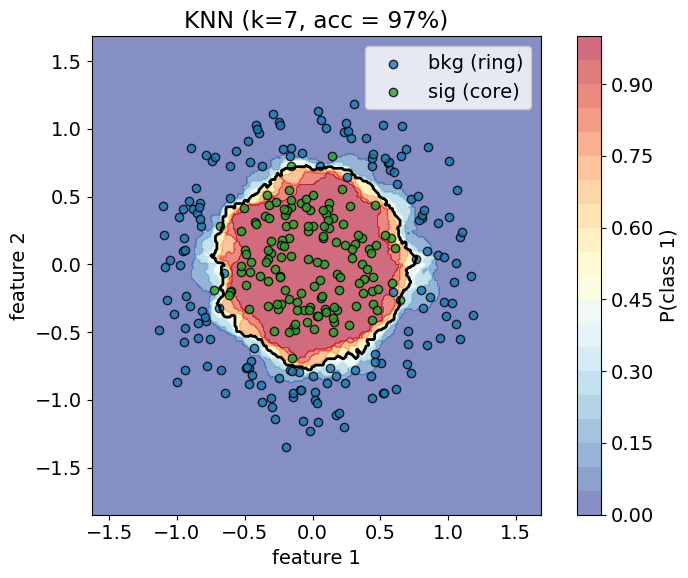

In [20]:
clf_knn = KNeighborsClassifier(n_neighbors=7)
clf_knn.fit(Xtr_c, ytr_c)

fig, axes = plt.subplots()
plot_decision_boundary(
    clf_knn, Xte_c, yte_c, ax=axes,
    title=f'KNN (k=7, acc = {clf_knn.score(Xte_c, yte_c):.0%})',
    feature_names=['feature 1', 'feature 2'],
    class_names=['bkg (ring)', 'sig (core)']
)
axes.set_aspect('equal')

plt.tight_layout()
plt.show()

KNN learns a **curved** boundary that wraps around the signal region — something no linear classifier can do.

### 3.3 ROC comparison

Let's compare both classifiers with the ROC curve.

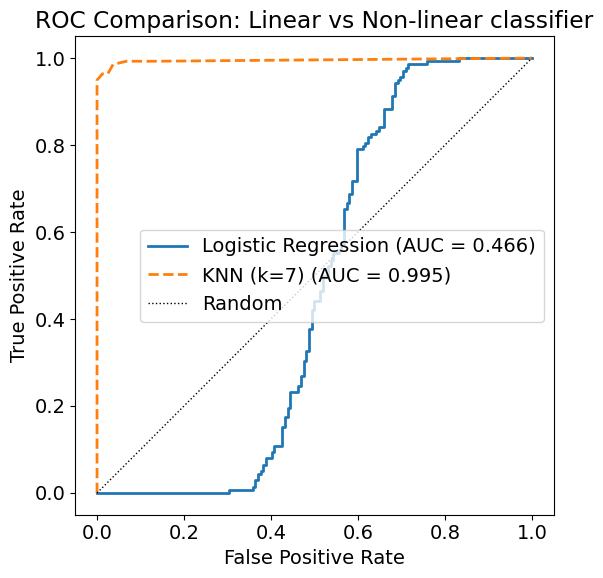

In [21]:
fig, ax = plt.subplots()

for clf, name, ls in [(clf_lr_circ, 'Logistic Regression', '-'), 
                       (clf_knn, 'KNN (k=7)', '--')]:
    y_prob_c = clf.predict_proba(Xte_c)[:, 1]
    fpr_c, tpr_c, _ = roc_curve(yte_c, y_prob_c)
    auc_c = auc(fpr_c, tpr_c)
    ax.plot(fpr_c, tpr_c, ls=ls, lw=2, label=f'{name} (AUC = {auc_c:.3f})')

ax.plot([0, 1], [0, 1], 'k:', lw=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
ax.set_title('ROC Comparison: Linear vs Non-linear classifier')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### 3.4 The effect of $k$

KNN has a hyperparameter $k$ that controls the bias-variance tradeoff — just like the polynomial order $M$ in curve fitting from Module 1, or the regularization strength $\lambda$.

- $k = 1$: boundary perfectly wraps every training point (overfits)
- $k = N$: every point is classified by majority class (underfits)

This is **model complexity** again — the same theme from Module 1.

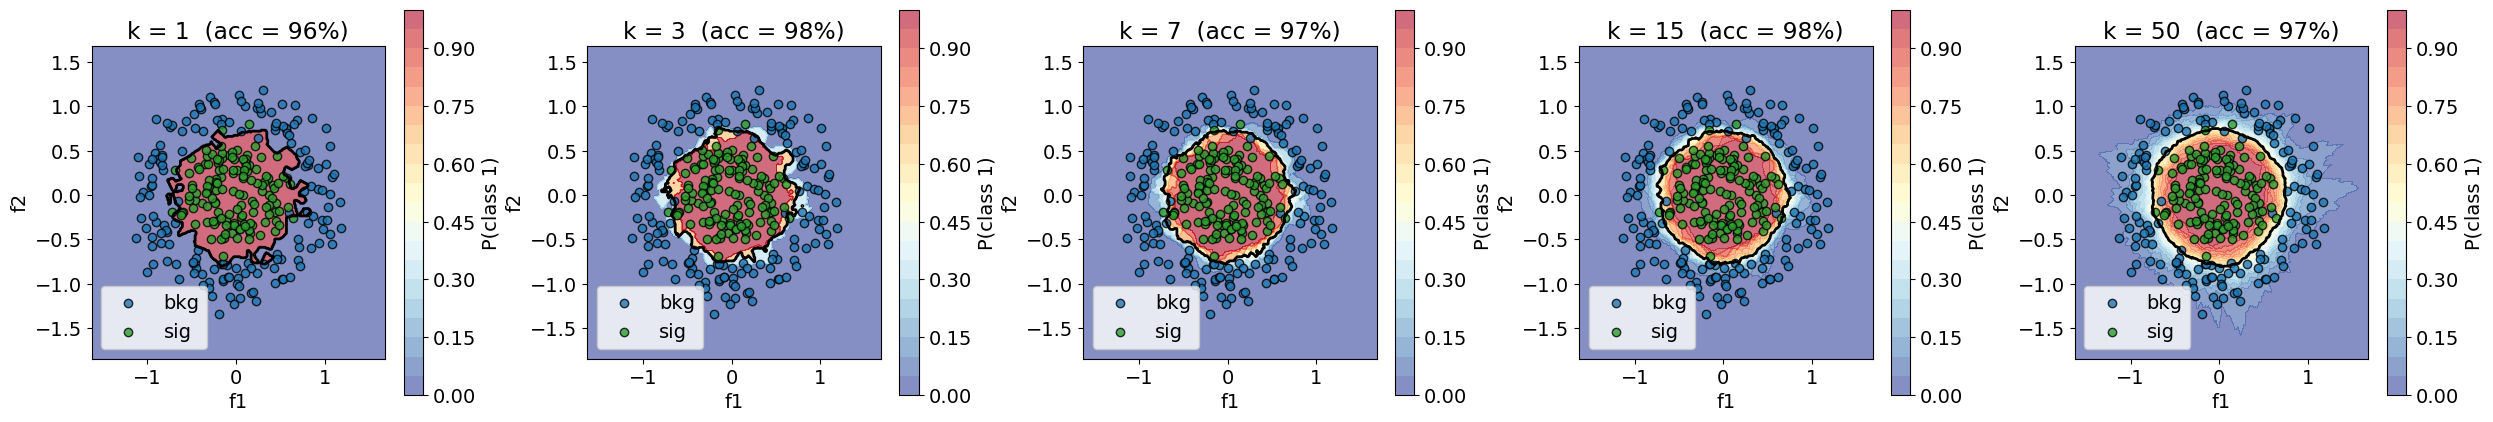

In [22]:
k_values = [1, 3, 7, 15, 50]

fig, axes = plt.subplots(1, len(k_values), figsize=(5 * len(k_values), 4.5))

for i, k in enumerate(k_values):
    clf_k = KNeighborsClassifier(n_neighbors=k)
    clf_k.fit(Xtr_c, ytr_c)
    acc_k = clf_k.score(Xte_c, yte_c)
    
    plot_decision_boundary(
        clf_k, Xte_c, yte_c, ax=axes[i],
        title=f'k = {k}  (acc = {acc_k:.0%})',
        feature_names=['f1', 'f2'],
        class_names=['bkg', 'sig']
    )
    axes[i].set_aspect('equal')

plt.tight_layout()
plt.show()

### 3.5 Back to the physics problem: does KNN help when the boundary is already linear?

An important sanity check. If the true boundary *is* linear (or close to it), KNN should do about the same as logistic regression — or slightly worse (because it doesn't know the boundary is linear and wastes capacity modeling noise).

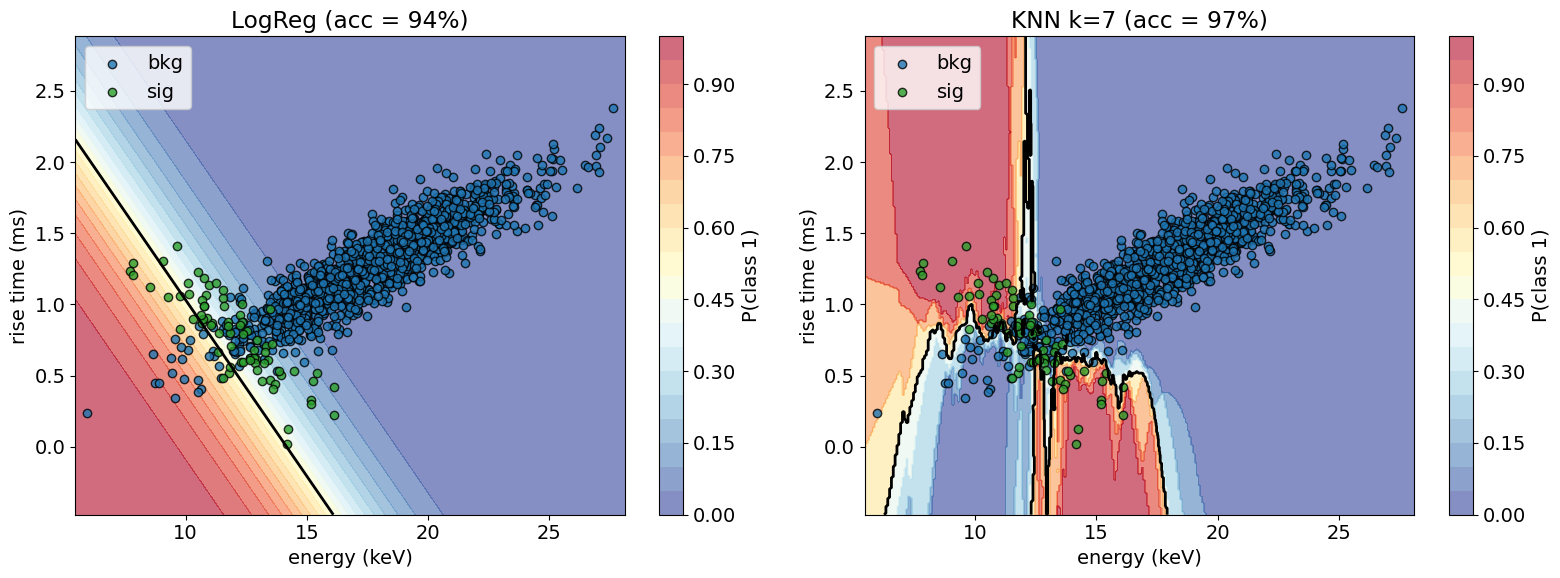

In [23]:
# Use our dark matter dataset (which has roughly linear boundary)
# Compare logistic regression vs KNN using 2 of the 3 features for visualization
X_dm_2d = X_dm[:, :2]  # energy and rise time only
Xtr_l, Xte_l, ytr_l, yte_l = train_test_split(
    X_dm_2d, y_dm, test_size=0.3, random_state=0, stratify=y_dm
)

clf_lr_lin = LogisticRegression().fit(Xtr_l, ytr_l)
clf_knn_lin = KNeighborsClassifier(n_neighbors=7).fit(Xtr_l, ytr_l)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_decision_boundary(
    clf_lr_lin, Xte_l, yte_l, ax=axes[0],
    title=f'LogReg (acc = {clf_lr_lin.score(Xte_l, yte_l):.0%})',
    feature_names=['energy (keV)', 'rise time (ms)'],
    class_names=['bkg', 'sig']
)

plot_decision_boundary(
    clf_knn_lin, Xte_l, yte_l, ax=axes[1],
    title=f'KNN k=7 (acc = {clf_knn_lin.score(Xte_l, yte_l):.0%})',
    feature_names=['energy (keV)', 'rise time (ms)'],
    class_names=['bkg', 'sig']
)

plt.tight_layout()
plt.show()

**Lesson:** When the problem *is* linear, the linear classifier is the right tool — it matches the structure of the problem. Using a more flexible model doesn't help and may hurt (noisy boundary).

This mirrors what we learned with polynomial regression: matching model complexity to the problem is the key.

---
## Summary and Takeaways

| | Logistic Regression | KNN |
|---|---|---|
| **Boundary shape** | Linear (hyperplane) | Arbitrary (adapts to data) |
| **Assumption** | Classes separated by a plane | Similar points have similar labels |
| **Parameters** | $\mathbf{w}, b$ (learned from data) | $k$ (chosen by you) |
| **Training** | Solve optimization | Just store the data |
| **Prediction** | Fast (dot product) | Slow (search all neighbors) |
| **When to use** | Linearly separable, or first baseline | Complex boundaries, low dimensions |

### The physicist's perspective

- **Always start with a linear classifier.** It is interpretable, fast, and often sufficient. It also directly connects to the statistical framework (likelihood ratios, Fisher discriminant) you already know.
- **If it fails**, ask: is the failure because my *features* are bad, or because the *boundary* is truly non-linear?
  - Better features (e.g., optimal filter amplitude instead of peak height) can make a non-linear problem linear.
  - If the boundary is fundamentally curved, then you need a non-linear method.
- **Model complexity is a spectrum**, just like polynomial order in curve fitting. $k$ in KNN, regularization $C$ in logistic regression, number of layers in a neural network — these all control the same tradeoff.

### What's next

In the next module, we will see how **neural networks** generalize the logistic regression idea by stacking many sigmoid units together — allowing the model to *learn* non-linear boundaries automatically.